In [1]:
# imports
from src.data_loader import load_data
from src.preprocess import prepare_data

from src.ML.train_svm import train_SVM
from src.ML.train_rf import train_random_forest
from src.ML.train_NN_improved import train_model as train_nn, TextClassifier, DeepTextClassifier, to_tensor, FocalLoss
from src.LM.lm_slovakBERT import train_model as train_model, evaluate_model, create_dataloaders, get_class_weights


from src.benchmarking import training_benchmark, inference_benchmark, count_parameters, build_comparison_table

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = '/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at gerulata/slovakbert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda


In [2]:
# load data
df = load_data(DATA_PATH)
print(f'Dataset size: {df.shape}')
print(df.iloc[:, -1].value_counts())  # class distribution

Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...
Dataset size: (694, 2)
Text
Mladá žena je vodičkou autobusu: Tie najhrubšie komentáre, ktoré som si kedy vypočula! Autobusári sú ľudia, ktorí nás prevážajú z bodu A do bodu B a nielenže musia fungovať v rušnej premávke, ale tiež musia zaistiť bezpečnosť všetk

Category
0    0.727666
1    0.272334
Name: proportion, dtype: float64
using devide: cuda
Loading pretrained MiniLM model 'sentence-transformers/all-MiniLM-L6-v2' from Hugging Face…
Minilm embedder loaded on device: cuda
Loaded embedding cache.
Saved cache with 1386 entries.
Embeddings created. Shape: (555, 384)
Categories:
 Category
0    0.727928
1    0.272072
Name: proportion, dtype: float64

SUPPORT VECTOR MACHINE (SVM)

--- SVM Model Input Data Summary ---
X_train Shape (samples, features): (555, 384)
X_train Data Type: float64
y_train Shape (labels): (555,)
y_train Data Type: int64
Feature Vector Length (input_dim): 384
Matrix Format: <class 'numpy.ndarray'>
------------------------------
First sample (first 10 embedding values):
[-0.0981397   0.12419126 -0.32490024  0.06120977 -0.34975445  0.0631097
  0.27390516 -0.24072687  0.10196473 -0.18389593]
------------------------------

Computed class weights:
  0: 0.6869
  1: 5.5132

Best C found via StratifiedKFold: 0.01

--- SVM CLASS

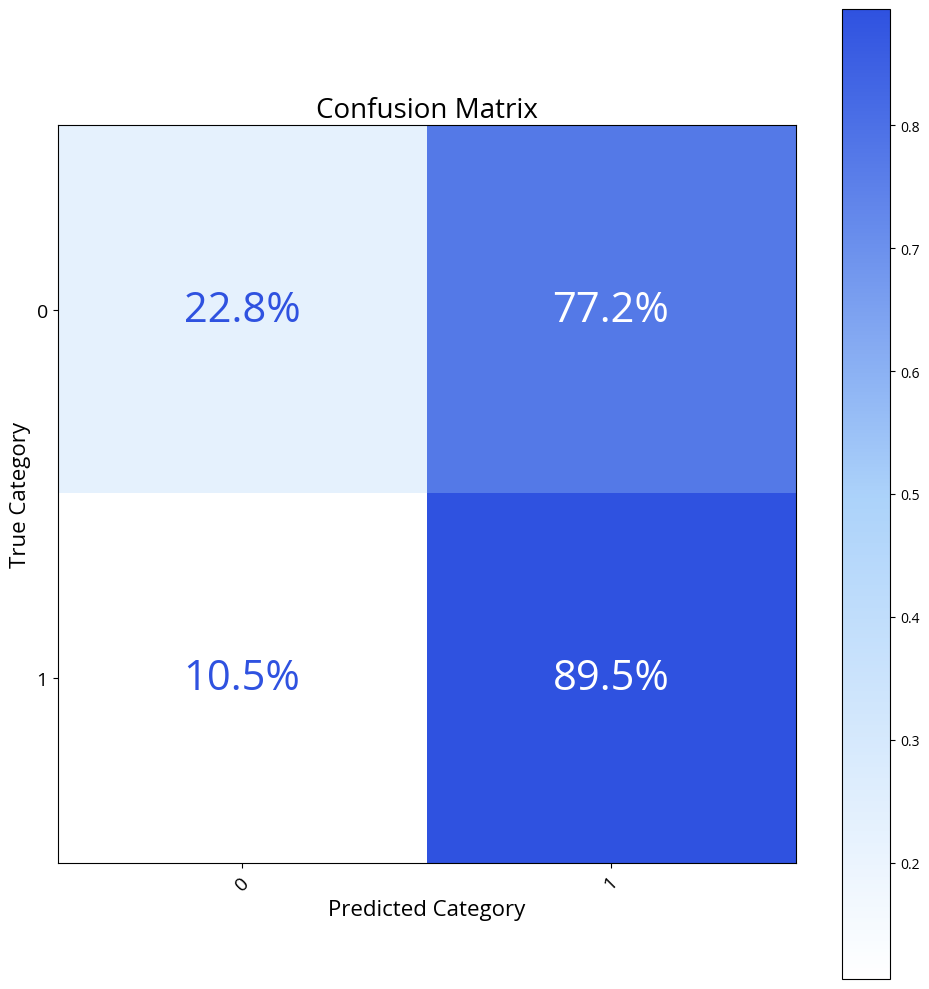

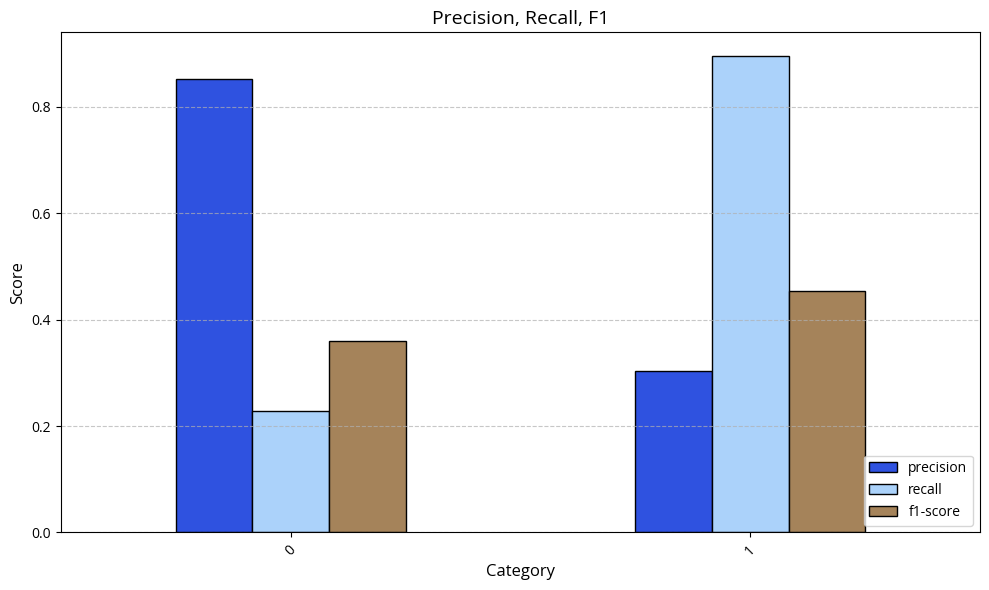

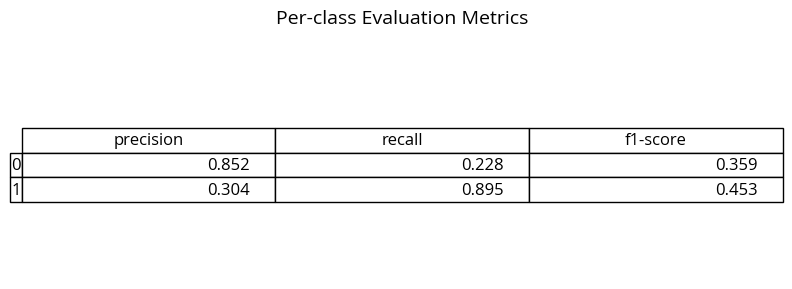


Training stats: {'training_time_s': 4.66, 'peak_ram_mb': 0.99, 'peak_gpu_mb': 0.55}
Inference stats: {'inference_time_s': 0.0003, 'per_sample_ms': 0.002}


In [3]:
#SVM
# pocetnost kategorii
from src.LM.embeddings.embedder_preprocess import load_minilm_embedder, prepare_data_minilm_simple
from src.ML.train_svm import train_SVM


print(df["Category"].value_counts(normalize=True))

# MiniLM embedder
device = "cuda" if torch.cuda.is_available() else "cpu"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)

minilm_model.eval()  # set to evaluation mode

# Convert text to minilm embeddings
X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)

print("Embeddings created. Shape:", X_train_vec.shape)
print("Categories:\n", y_train.value_counts(normalize=True))

target_names = [str(t) for t in sorted(y_train.unique())]



#svm_model = train_SVM(X_train_vec, y_train, X_test_vec, y_test, target_names, boost_factor = 3.0)


(svm_model, svm_preds, svm_true), svm_train_stats = training_benchmark(
    lambda: train_SVM(X_train_vec, y_train, X_test_vec, y_test, target_names, boost_factor = 3.0)
)

_, svm_inf_stats = inference_benchmark(
    lambda X: svm_model.predict(X), X_test_vec
)

print('\nTraining stats:', svm_train_stats)
print('Inference stats:', svm_inf_stats)

Category
0    0.727666
1    0.272334
Name: proportion, dtype: float64
using devide: cuda
Loading pretrained MiniLM model 'sentence-transformers/all-MiniLM-L6-v2' from Hugging Face…
Minilm embedder loaded on device: cuda
Loaded embedding cache.
Saved cache with 1386 entries.
Embeddings created. Shape: (555, 384)
Categories:
 Category
0    0.727928
1    0.272072
Name: proportion, dtype: float64

RANDOM FOREST

--- RF Model Input Data Summary ---
X_train Shape (samples, features): (555, 384)
X_train Data Type: float64
y_train Shape (labels): (555,)
y_train Data Type: int64
Feature Vector Length (input_dim): 384
Matrix Format: <class 'numpy.ndarray'>
------------------------------
First sample (first 10 embedding values):
Prvá vzorka (prvých 10 TF-IDF hodnôt):
[-0.0981397   0.12419126 -0.32490024  0.06120977 -0.34975445  0.0631097
  0.27390516 -0.24072687  0.10196473 -0.18389593]
------------------------------
Original class weights: [0.68688119 1.83774834]
Boosted class weights: [0.686881

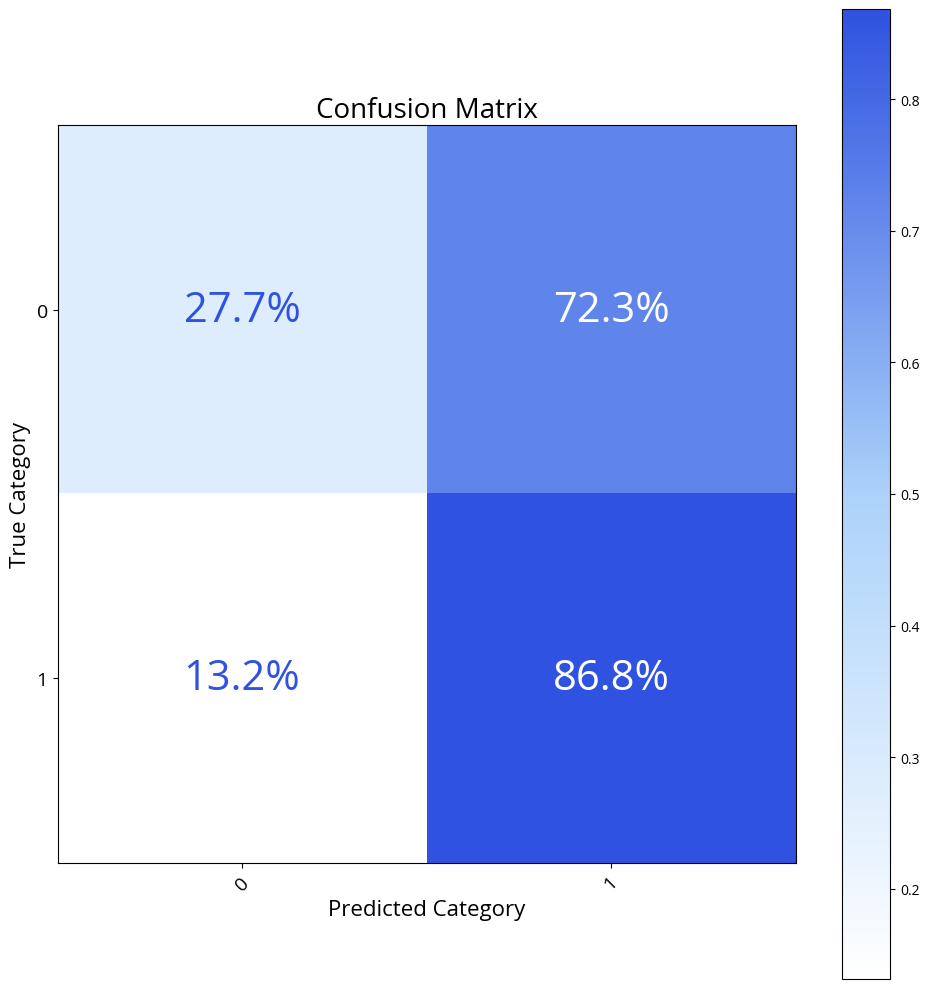

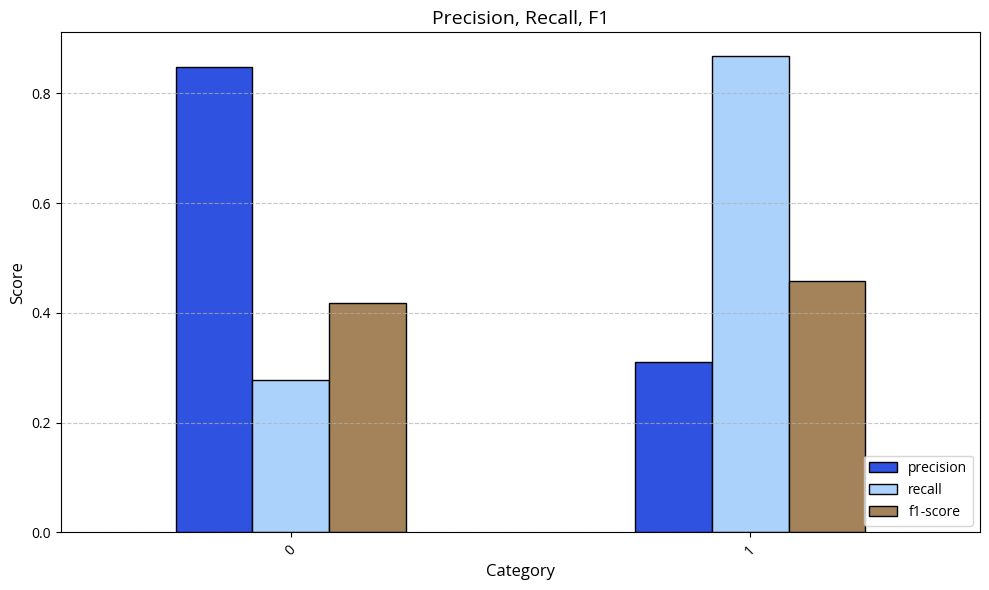

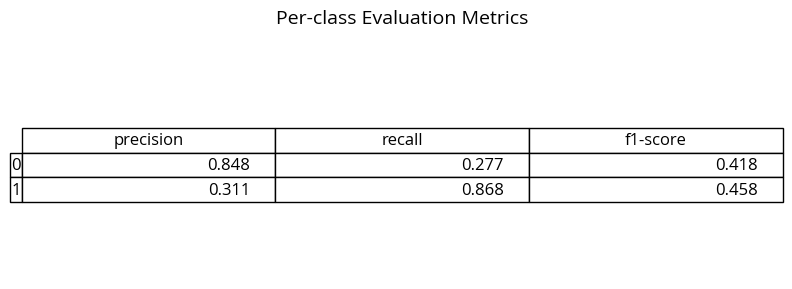


Training stats: {'training_time_s': 11.32, 'peak_ram_mb': 1.04, 'peak_gpu_mb': 0.55}
Inference stats: {'inference_time_s': 0.028, 'per_sample_ms': 0.2015}


In [4]:
from src.LM.embeddings.embedder_preprocess import load_minilm_embedder, prepare_data_minilm_simple
# Random Forest
# pocetnost kategorii
print(df["Category"].value_counts(normalize=True))

# MiniLM embedder
device = "cuda" if torch.cuda.is_available() else "cpu"
print('using devide:', device)
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device)

minilm_model.eval()  # set to evaluation mode

# Convert text to minilm embeddings
X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm_simple(df, tokenizer, minilm_model, device=device)

print("Embeddings created. Shape:", X_train_vec.shape)
print("Categories:\n", y_train.value_counts(normalize=True))

target_names = [str(t) for t in sorted(y_train.unique())]



#rf_model = train_random_forest(X_train_vec, y_train, X_test_vec, y_test, target_names, boost_factor = 2.1)

(rf_model, rf_preds, rf_true), rf_train_stats = training_benchmark(
    lambda: train_random_forest(X_train_vec, y_train, X_test_vec, y_test, target_names, boost_factor = 2.1)
)

_, rf_inf_stats = inference_benchmark(
    lambda X: rf_model.predict(X), X_test_vec
)

print('\nTraining stats:', rf_train_stats)
print('Inference stats:', rf_inf_stats)

In [5]:
# Simple NN
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

alpha = torch.tensor([1.0, 3.0])

nn_result, simple_nn_train_stats = training_benchmark(
    lambda: train_nn(
        X_train, y_train, X_test, y_test,
        model_class=TextClassifier,
        model_params={'hidden_dim': 256},
        epochs=130,
        lr=1e-5,
        loss_fn=FocalLoss(alpha=alpha, gamma=2),
        use_scheduler=True
    )
)

simple_nn, class_to_idx, nn_preds, nn_true, nn_losses, nn_accs = nn_result

X_test_t = to_tensor(X_test).to(device)
simple_nn.eval()
_, simple_nn_inf_stats = inference_benchmark(
    lambda X: simple_nn(X).argmax(dim=1).cpu().numpy(), X_test_t
)

_, simple_nn_trainable_params = count_parameters(simple_nn)

print('\nTraining stats:', simple_nn_train_stats)
print('Inference stats:', simple_nn_inf_stats)
print('Parameters:', simple_nn_trainable_params)



/home/xkubanova_126831/bakalarka/nbs_binary/src/ML/train_NN_improved.py:87: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))  # <-- register_buffer keeps it with the model



Training stats: {'training_time_s': 6.41, 'peak_ram_mb': 1.44, 'peak_gpu_mb': 0.58}
Inference stats: {'inference_time_s': 0.0004, 'per_sample_ms': 0.0026}
Parameters: 768770


In [6]:
# Deep NN

X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

alpha = torch.tensor([1.0, 3.0])

nn_result, deep_nn_train_stats = training_benchmark(
    lambda: train_nn(
        X_train, y_train, X_test, y_test,
        model_class=DeepTextClassifier,
        model_params={'hidden_dims': [256, 128, 64, 32]},
        epochs=150,
        lr=1e-4,
        loss_fn=FocalLoss(alpha=alpha, gamma=2),
        use_scheduler=True
    )
)

deep_nn, class_to_idx, deep_preds, deep_true, deep_losses, deep_accs = nn_result

X_test_t = to_tensor(X_test).to(device)
deep_nn.eval()
_, deep_nn_inf_stats = inference_benchmark(
    lambda X: deep_nn(X).argmax(dim=1).cpu().numpy(), X_test_t
)

_, deep_nn_trainable_params = count_parameters(deep_nn)

print('\nTraining stats:', deep_nn_train_stats)
print('Inference stats:', deep_nn_inf_stats)
print('Parameters:', deep_nn_trainable_params)


/home/xkubanova_126831/bakalarka/nbs_binary/src/ML/train_NN_improved.py:87: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))  # <-- register_buffer keeps it with the model



Training stats: {'training_time_s': 10.44, 'peak_ram_mb': 1.45, 'peak_gpu_mb': 0.59}
Inference stats: {'inference_time_s': 0.0009, 'per_sample_ms': 0.0066}
Parameters: 811554


Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...
Target names: [0, 1]
Label distribution:
Category_encoded
0    505
1    189
Name: count, dtype: int64
Train size: 555
Test size: 139


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at gerulata/slovakbert and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5, Loss: 0.1459
Epoch 2/5, Loss: 0.1042
Epoch 3/5, Loss: 0.0674
Epoch 4/5, Loss: 0.0602
Epoch 5/5, Loss: 0.0584
Best threshold (F1-optimal): 0.789
Best F1 score: 0.735| Precision: 0.833 | Recall: 0.658

Recall-optimal threshold: 0.496
F1: 0.655 | Precision: 0.500 | Recall: 0.947
              precision    recall  f1-score   support

           0       0.97      0.64      0.77       101
           1       0.50      0.95      0.65        38

    accuracy                           0.73       139
   macro avg       0.74      0.80      0.71       139
weighted avg       0.84      0.73      0.74       139



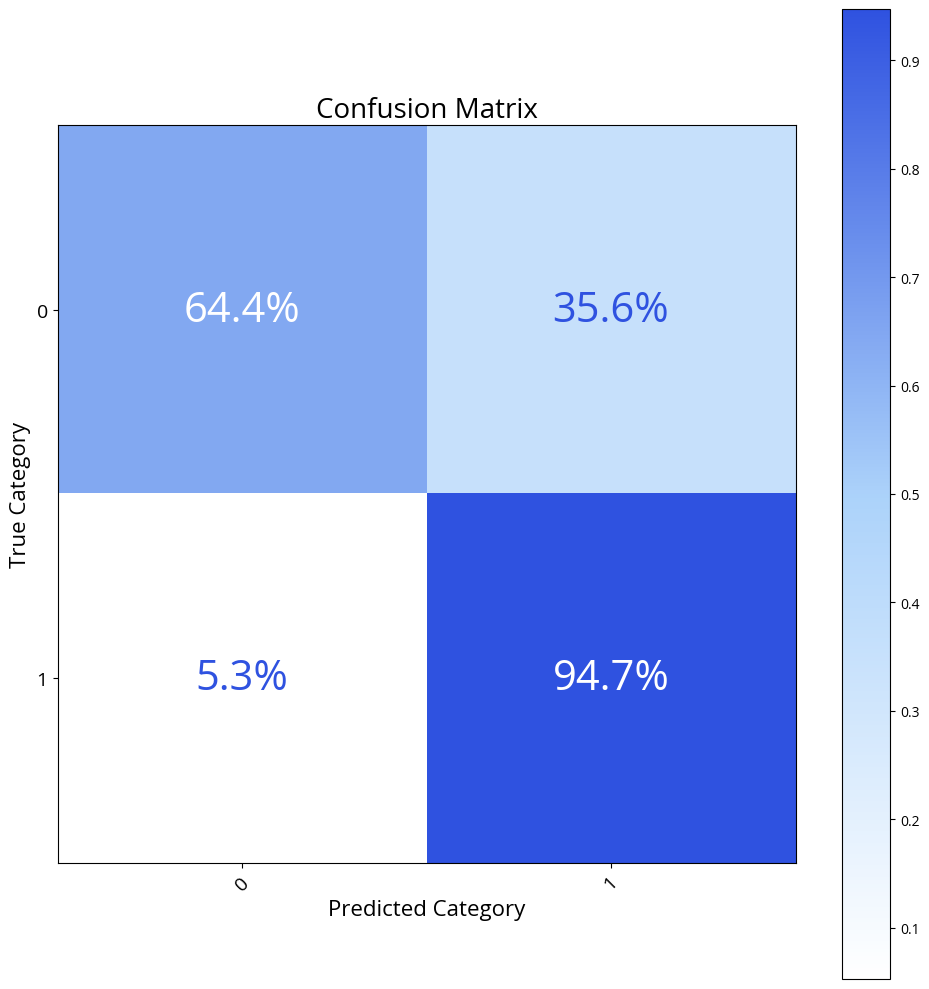

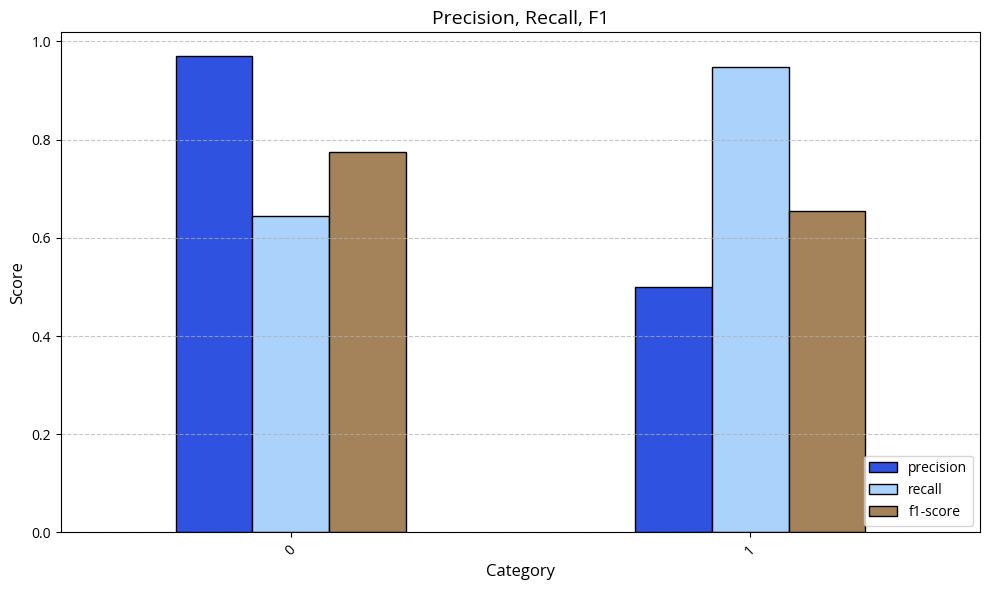

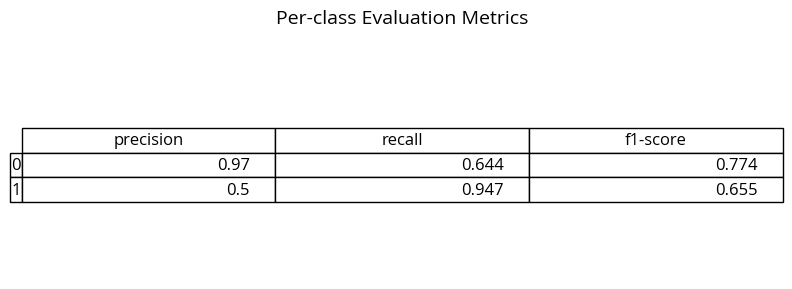

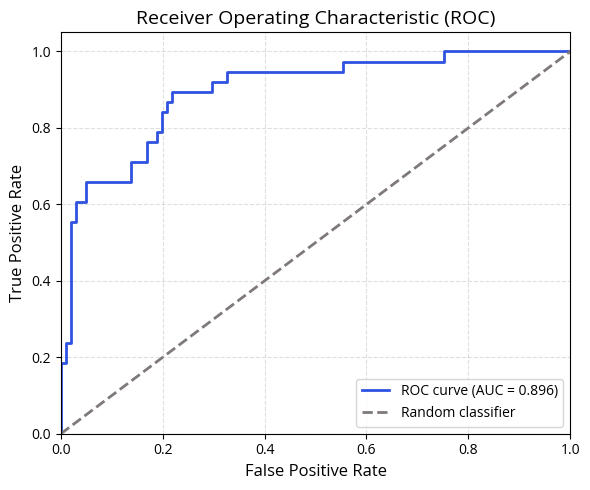

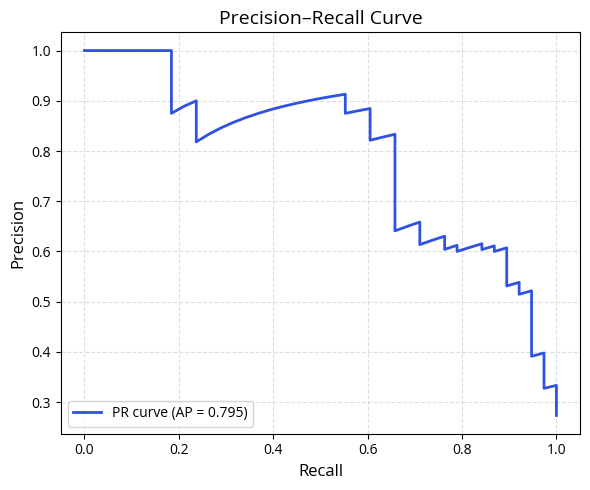


Training stats: {'training_time_s': 15.5, 'peak_ram_mb': 1.56, 'peak_gpu_mb': 4.88}
Inference stats: {'inference_time_s': 1.2338, 'per_sample_ms': 8.8762}
Parameters: 124646402


In [7]:
# SlovakBERT
from sklearn.calibration import LabelEncoder
from sklearn.calibration import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification
from src.preprocess import clean_text
from src.LM.lm_slovakBERT import model as bert_model, tokenizer
from src.LM.lm_slovakBERT import train_model as train_bert, evaluate_model, create_dataloaders, get_class_weights



df = load_data("/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv")
df['Text'] = df['Text'].apply(clean_text)  

le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])

# ulozenie katagorii
target_names = le.classes_.tolist()

print("Target names:", target_names)
print("Label distribution:")
print(df["Category_encoded"].value_counts())


X_train_text, X_test_text, y_train_encoded, y_test_encoded = train_test_split(
    df['Text'].tolist(), 
    df['Category_encoded'].tolist(),
    test_size=0.2, 
    random_state=42,
    stratify=df['Category_encoded']
)
print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

train_loader, test_loader = create_dataloaders(X_train_text, y_train_encoded, X_test_text, y_test_encoded)
class_weights = get_class_weights(y_train_encoded, device)



def init_fresh_bert():
    fresh_model = AutoModelForSequenceClassification.from_pretrained(
        "gerulata/slovakbert",
        num_labels=2
    ).to(device)
    # reapply layer freezing
    for name, param in fresh_model.named_parameters():
        if name.startswith("bert.embeddings") or name.startswith("bert.encoder.layer.0"):
            param.requires_grad = False
    return fresh_model

bert_result, bert_train_stats = training_benchmark(
    lambda: train_bert(
        init_fresh_bert(), train_loader,
        epochs=5,
        lr=1e-5,
        use_focal_loss=True,
        class_weights=class_weights
    )
)
bert_trained = bert_result

_, bert_inf_stats = inference_benchmark(
    lambda X: evaluate_model(bert_trained, test_loader, label_names=target_names),
    X_test_text
)

_, bert_trainable_params = count_parameters(bert_trained)

print('\nTraining stats:', bert_train_stats)
print('Inference stats:', bert_inf_stats)
print('Parameters:', bert_trainable_params)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...
Target names: [0, 1]
Label distribution:
Category_encoded
0    505
1    189
Name: count, dtype: int64
Train size: 555
Test size: 139


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/6, Loss: 0.2007
Epoch 2/6, Loss: 0.1454
Epoch 3/6, Loss: 0.1234
Epoch 4/6, Loss: 0.0910
Epoch 5/6, Loss: 0.0681
Epoch 6/6, Loss: 0.0632
Best threshold (F1-optimal): 0.471
Best F1 score: 0.692

Recall-optimal threshold: 0.416
F1: 0.655 | Precision: 0.500 | Recall: 0.947
              precision    recall  f1-score   support

           0       0.97      0.64      0.77       101
           1       0.50      0.95      0.65        38

    accuracy                           0.73       139
   macro avg       0.74      0.80      0.71       139
weighted avg       0.84      0.73      0.74       139



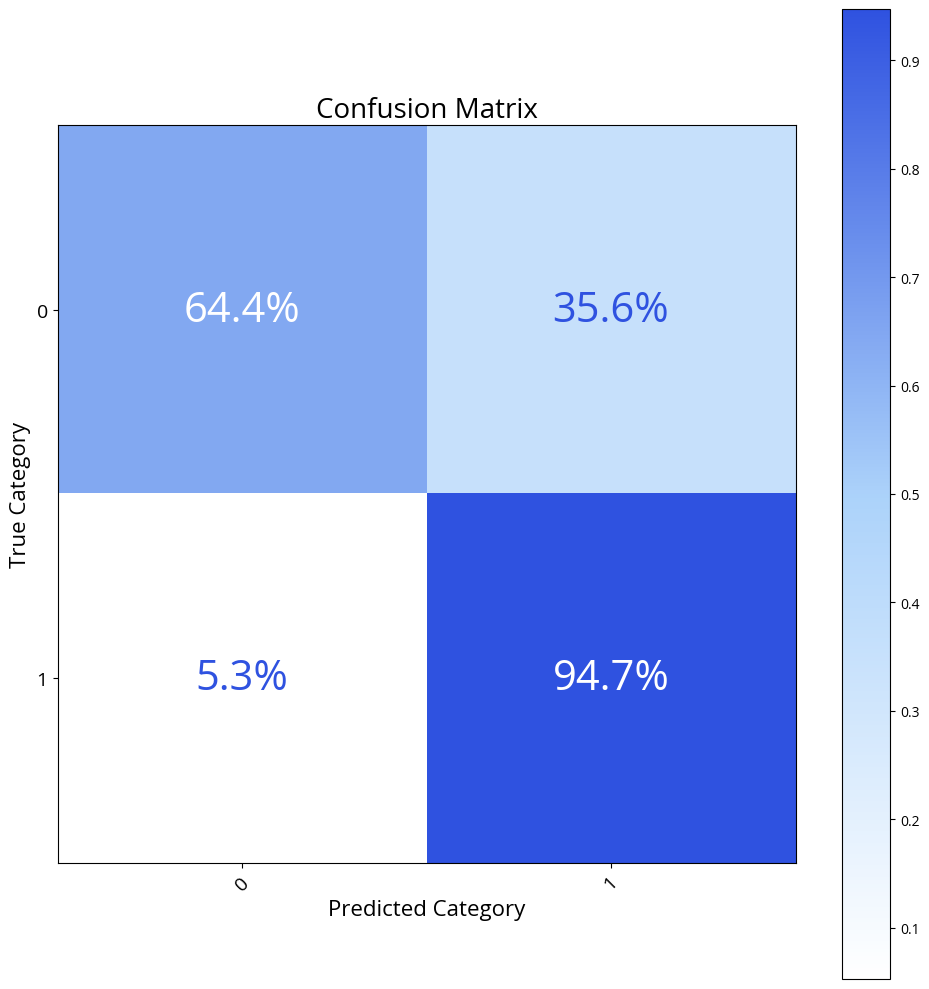

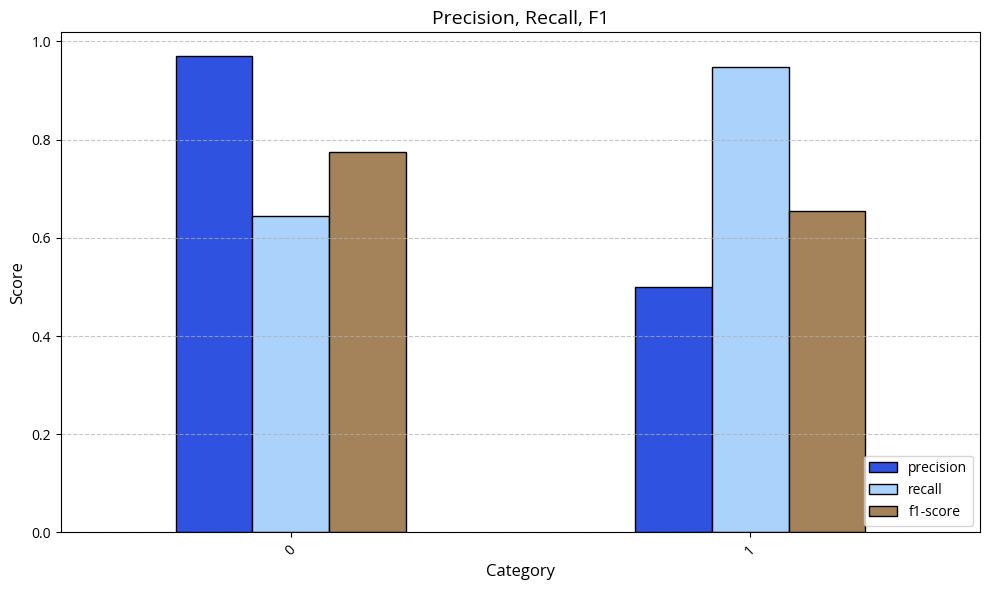

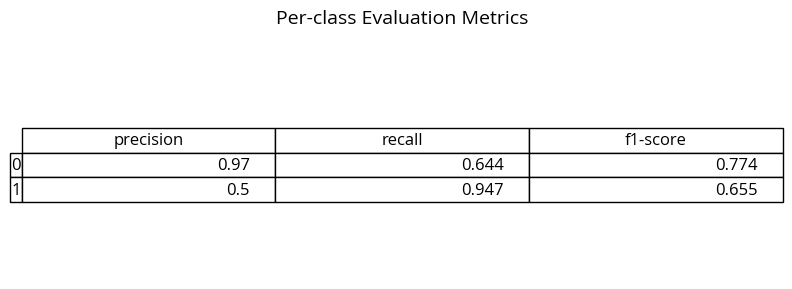

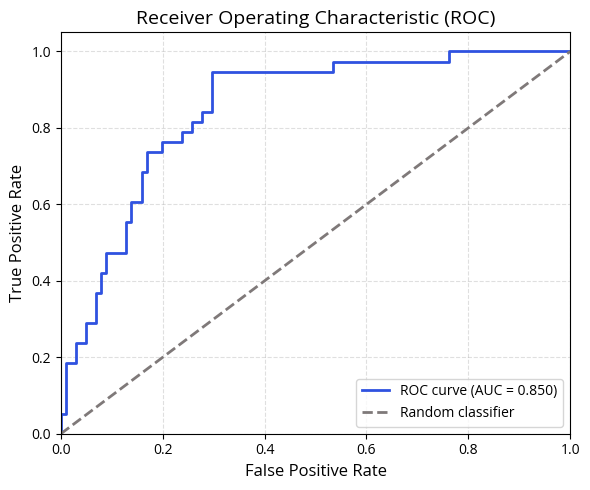

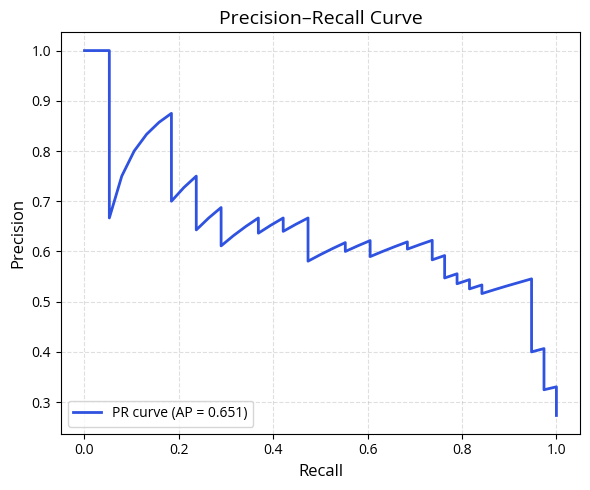


Training stats: {'training_time_s': 23.42, 'peak_ram_mb': 1.85, 'peak_gpu_mb': 9.62}
Inference stats: {'inference_time_s': 1.2031, 'per_sample_ms': 8.6555}
Parameters: 278045186


In [8]:
# Roberta XML 
from sklearn.calibration import LabelEncoder
from sklearn.calibration import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification
from src.preprocess import clean_text
from src.LM.lm_roberta_xml import model as roberta_model, tokenizer
from src.LM.lm_roberta_xml import train_model as train_roberta, evaluate_model, create_dataloaders, get_class_weights



df = load_data("/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv")
df['Text'] = df['Text'].apply(clean_text)  

le = LabelEncoder()
df['Category_encoded'] = le.fit_transform(df['Category'])

# ulozenie katagorii
target_names = le.classes_.tolist()

print("Target names:", target_names)
print("Label distribution:")
print(df["Category_encoded"].value_counts())


X_train_text, X_test_text, y_train_encoded, y_test_encoded = train_test_split(
    df['Text'].tolist(), 
    df['Category_encoded'].tolist(),
    test_size=0.2, 
    random_state=42,
    stratify=df['Category_encoded']
)
print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

train_loader, test_loader = create_dataloaders(X_train_text, y_train_encoded, X_test_text, y_test_encoded)
class_weights = get_class_weights(y_train_encoded, device)



def init_fresh_roberta():
    fresh_model = AutoModelForSequenceClassification.from_pretrained(
        "xlm-roberta-base",
        num_labels=2
    ).to(device)
    # reapply layer freezing
    for name, param in fresh_model.named_parameters():
        if name.startswith("bert.embeddings") or name.startswith("bert.encoder.layer.0"):
            param.requires_grad = False
    return fresh_model


roberta_result, roberta_train_stats = training_benchmark(
    lambda: train_roberta(
        init_fresh_roberta(), train_loader,
        epochs=6,
        lr=2e-5,
        use_focal_loss=True,
        class_weights=class_weights
    )
)
roberta_trained = roberta_result

_, roberta_inf_stats = inference_benchmark(
    lambda X: evaluate_model(roberta_trained, test_loader, label_names=target_names),
    X_test_text
)

_, roberta_trainable_params = count_parameters(roberta_trained)
print('\nTraining stats:', roberta_train_stats)
print('Inference stats:', roberta_inf_stats)
print('Parameters:', roberta_trainable_params)

In [9]:
# fill in macro_f1 values from your classification reports

for name, var in [
    ('svm_train_stats',      svm_train_stats),
    ('svm_inf_stats',        svm_inf_stats),
    ('rf_train_stats',       rf_train_stats),
    ('rf_inf_stats',         rf_inf_stats),
    ('simple_nn_train_stats', simple_nn_train_stats),
    ('simple_nn_inf_stats',  simple_nn_inf_stats),
    ('deep_nn_train_stats',  deep_nn_train_stats),
    ('deep_nn_inf_stats',    deep_nn_inf_stats),
    ('bert_train_stats',     bert_train_stats),
    ('bert_inf_stats',       bert_inf_stats),
    ('roberta_train_stats',     roberta_train_stats),
    ('roberta_inf_stats',       roberta_inf_stats),
]:
    print(f"{name}: {var}")



results = {
    'SVM': {
        'training_time_s':         svm_train_stats['training_time_s'],
        'per_sample_ms':           svm_inf_stats['per_sample_ms'],
        'peak_ram_mb':             svm_train_stats['peak_ram_mb'],
        'peak_gpu_mb':             0,
        'trainable_params':        'N/A',
        'macro_f1':                0.41,
        'recall_1':                0.89, 
    },
    'Random Forest': {
        'training_time_s':         rf_train_stats['training_time_s'],
        'per_sample_ms':           rf_inf_stats['per_sample_ms'],
        'peak_ram_mb':             rf_train_stats['peak_ram_mb'],
        'peak_gpu_mb':             0,
        'trainable_params':        'N/A',
        'macro_f1':                0.44,
        'recall_1':                0.87, 
    },
    'Simple NN': {
        'training_time_s':         simple_nn_train_stats['training_time_s'],
        'per_sample_ms':           simple_nn_inf_stats['per_sample_ms'],
        'peak_ram_mb':             simple_nn_train_stats['peak_ram_mb'],
        'peak_gpu_mb':             simple_nn_train_stats['peak_gpu_mb'],
        'trainable_params':        simple_nn_trainable_params,
        'macro_f1':                0.69,
        'recall_1':                0.66, 
    },
    'Deep NN': {
        'training_time_s':         deep_nn_train_stats['training_time_s'],
        'per_sample_ms':           deep_nn_inf_stats['per_sample_ms'],
        'peak_ram_mb':             deep_nn_train_stats['peak_ram_mb'],
        'peak_gpu_mb':             deep_nn_train_stats['peak_gpu_mb'],
        'trainable_params':        deep_nn_trainable_params,
        'macro_f1':                0.64,
        'recall_1':                0.87, 
    },
    'SlovakBERT': {
        'training_time_s':         bert_train_stats['training_time_s'],
        'per_sample_ms':           bert_inf_stats['per_sample_ms'],
        'peak_ram_mb':             bert_train_stats['peak_ram_mb'],
        'peak_gpu_mb':             bert_train_stats['peak_gpu_mb'],
        'trainable_params':        bert_trainable_params,
        'macro_f1':                0.74,
        'recall_1':                0.97, 
    },
    'RobertaXML': {
        'training_time_s':         roberta_train_stats['training_time_s'],
        'per_sample_ms':           roberta_inf_stats['per_sample_ms'],
        'peak_ram_mb':             roberta_train_stats['peak_ram_mb'],
        'peak_gpu_mb':             roberta_train_stats['peak_gpu_mb'],
        'trainable_params':        roberta_trainable_params,
        'macro_f1':                0.72,
        'recall_1':                0.97, 
    },
}

for model_name, model_stats in results.items():
    print(f"\n{model_name}:")
    for k, v in model_stats.items():
        print(f"  {k}: {type(v)} = {v}")

df_results = build_comparison_table(results)
df_results

svm_train_stats: {'training_time_s': 4.66, 'peak_ram_mb': 0.99, 'peak_gpu_mb': 0.55}
svm_inf_stats: {'inference_time_s': 0.0003, 'per_sample_ms': 0.002}
rf_train_stats: {'training_time_s': 11.32, 'peak_ram_mb': 1.04, 'peak_gpu_mb': 0.55}
rf_inf_stats: {'inference_time_s': 0.028, 'per_sample_ms': 0.2015}
simple_nn_train_stats: {'training_time_s': 6.41, 'peak_ram_mb': 1.44, 'peak_gpu_mb': 0.58}
simple_nn_inf_stats: {'inference_time_s': 0.0004, 'per_sample_ms': 0.0026}
deep_nn_train_stats: {'training_time_s': 10.44, 'peak_ram_mb': 1.45, 'peak_gpu_mb': 0.59}
deep_nn_inf_stats: {'inference_time_s': 0.0009, 'per_sample_ms': 0.0066}
bert_train_stats: {'training_time_s': 15.5, 'peak_ram_mb': 1.56, 'peak_gpu_mb': 4.88}
bert_inf_stats: {'inference_time_s': 1.2338, 'per_sample_ms': 8.8762}
roberta_train_stats: {'training_time_s': 23.42, 'peak_ram_mb': 1.85, 'peak_gpu_mb': 9.62}
roberta_inf_stats: {'inference_time_s': 1.2031, 'per_sample_ms': 8.6555}

SVM:
  training_time_s: <class 'float'> = 4.66

,training_time_s,per_sample_ms,peak_ram_mb,peak_gpu_mb,trainable_params,macro_f1,recall_1
SVM,4.66,0.002,0.99,0,N/A,0.41,0.89
Random Forest,11.32,0.2015,1.04,0,N/A,0.44,0.87
Simple NN,6.41,0.0026,1.44,0.58,768770.0,0.69,0.66
Deep NN,10.44,0.0066,1.45,0.59,811554.0,0.64,0.87
SlovakBERT,15.5,8.8762,1.56,4.88,124646402.0,0.74,0.97
RobertaXML,23.42,8.6555,1.85,9.62,278045186.0,0.72,0.97


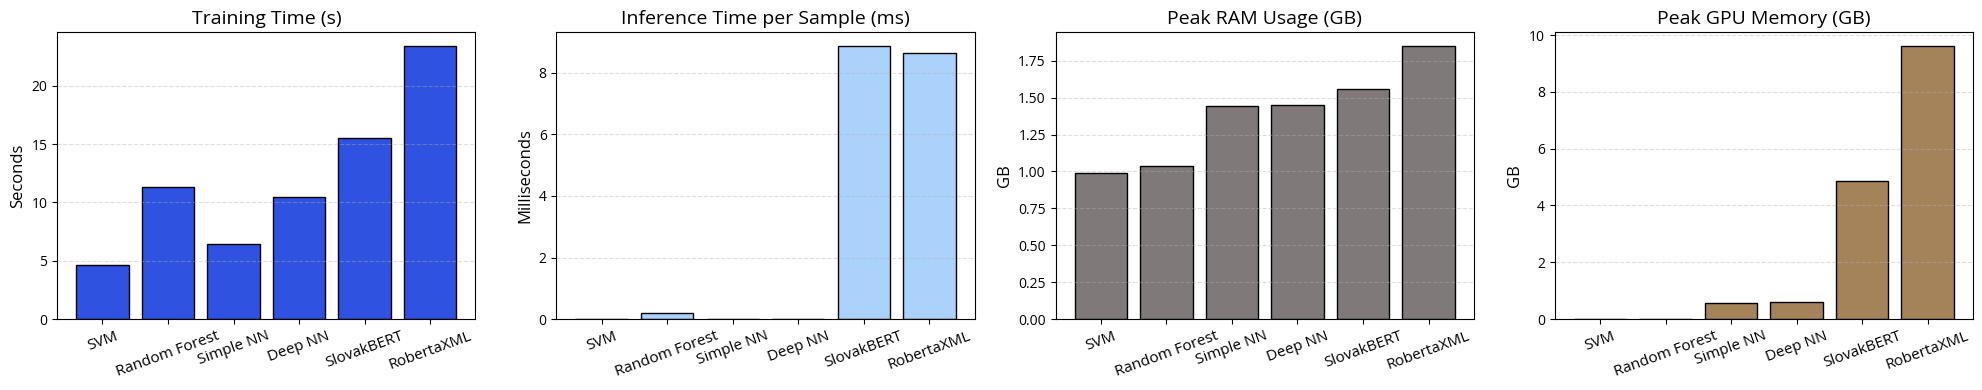

In [10]:
import matplotlib.font_manager as fm

# Path to your font file
font_path ="/home/xkubanova_126831/bakalarka/font/Open_Sans/OpenSans-VariableFont_wdth,wght.ttf"

# Register font
fm.fontManager.addfont(font_path)

# Set as default font
plt.rcParams['font.family'] = 'Open Sans'

PRIMARY = '#2f52e0'
SECONDARY = '#abd2fa'
NEUTRAL = '#7f7979'
ACCENT = '#a5835a'

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

models = df_results.index.tolist()

# Training time
axes[0].bar(models, df_results['training_time_s'],
            color=PRIMARY,
            edgecolor='black')

axes[0].set_title('Training Time (s)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Seconds', fontsize=12)
axes[0].tick_params(axis='x', rotation=20, labelsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)


# Inference time per sample
axes[1].bar(models, df_results['per_sample_ms'],
            color=SECONDARY,
            edgecolor='black')

axes[1].set_title('Inference Time per Sample (ms)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Milliseconds', fontsize=12)
axes[1].tick_params(axis='x', rotation=20, labelsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)


# Peak RAM
axes[2].bar(models, df_results['peak_ram_mb'],
            color=NEUTRAL,
            edgecolor='black')

axes[2].set_title('Peak RAM Usage (GB)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('GB', fontsize=12)
axes[2].tick_params(axis='x', rotation=20, labelsize=11)
axes[2].grid(axis='y', linestyle='--', alpha=0.4)


# Peak GPU
axes[3].bar(models, df_results['peak_gpu_mb'],
            color=ACCENT,
            edgecolor='black')

axes[3].set_title('Peak GPU Memory (GB)', fontsize=14, fontweight='bold')
axes[3].set_ylabel('GB', fontsize=12)
axes[3].tick_params(axis='x', rotation=20, labelsize=11)
axes[3].grid(axis='y', linestyle='--', alpha=0.4)


plt.tight_layout()

plt.savefig(
    'comparison_compute.png',
    dpi=300,                 # better for thesis
    bbox_inches='tight'
)

plt.show()

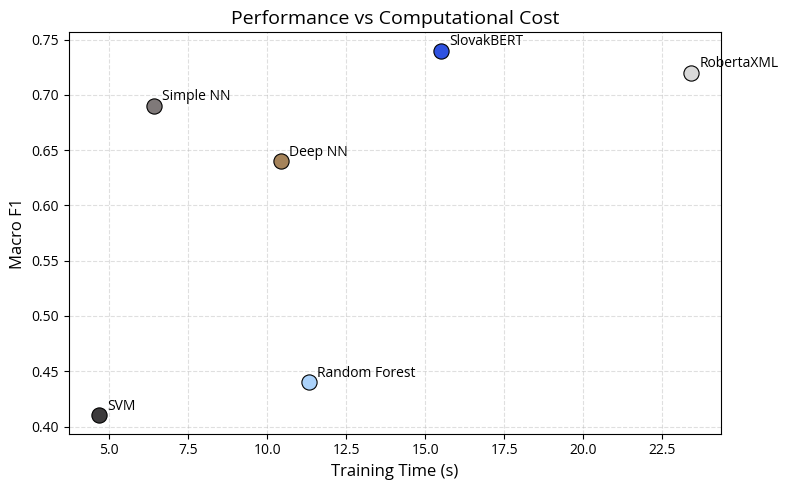

In [11]:
import matplotlib.font_manager as fm

# Path to your font file
font_path ="/home/xkubanova_126831/bakalarka/font/Open_Sans/OpenSans-VariableFont_wdth,wght.ttf"

# Register font
fm.fontManager.addfont(font_path)

# Set as default font
plt.rcParams['font.family'] = 'Open Sans'


PRIMARY = '#2f52e0'
SECONDARY = '#abd2fa'
NEUTRAL = '#7f7979'
NEUTRAL_DARK = '#3d3b3c'
ACCENT = '#a5835a'
NEUTRAL_LIGHT = '#d9d9d9'

model_colors = {
    'SVM': NEUTRAL_DARK,
    'Random Forest': SECONDARY,
    'Simple NN': NEUTRAL,
    'Deep NN': ACCENT,
    'SlovakBERT': PRIMARY,
    'RobertaXML': NEUTRAL_LIGHT, 
}

fig, ax = plt.subplots(figsize=(8, 5))

for model_name, row in df_results.iterrows():

    if row['macro_f1'] is not None:

        color = model_colors.get(model_name, PRIMARY)

        ax.scatter(
            row['training_time_s'],
            row['macro_f1'],
            s=120,
            color=color,
            edgecolor='black',
            linewidth=0.8
        )

        ax.annotate(
            model_name,
            (row['training_time_s'], row['macro_f1']),
            textcoords='offset points',
            xytext=(6, 4),
            fontsize=10
        )

ax.set_xlabel('Training Time (s)', fontsize=12)
ax.set_ylabel('Macro F1', fontsize=12)

ax.set_title(
    'Performance vs Computational Cost',
    fontsize=14,
    fontweight='bold'
)

ax.grid(
    True,
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    'comparison_tradeoff.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

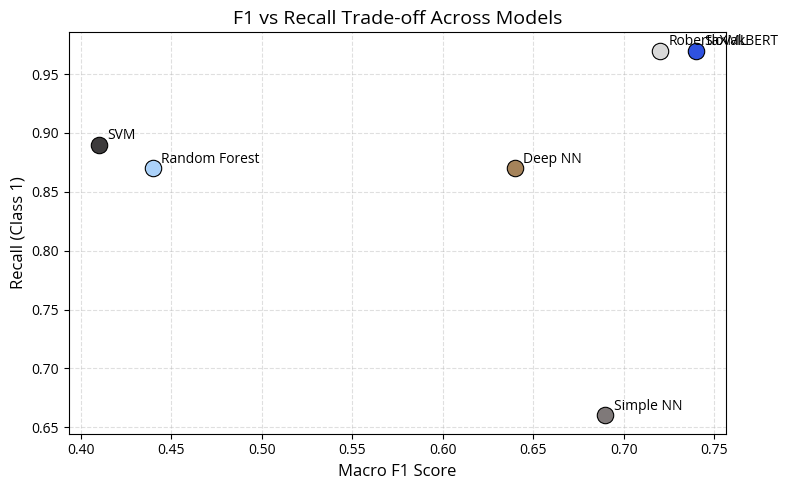

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

for model_name, row in df_results.iterrows():

    if row['macro_f1'] is not None and row['recall_1'] is not None:

        color = model_colors.get(model_name, PRIMARY)

        ax.scatter(
            row['macro_f1'],        
            row['recall_1'],          
            s=140,
            color=color,
            edgecolor='black',
            linewidth=0.8
        )

        ax.annotate(
            model_name,
            (row['macro_f1'], row['recall_1']),
            textcoords='offset points',
            xytext=(6, 4),
            fontsize=10
        )

# axis labels
ax.set_xlabel('Macro F1 Score', fontsize=12)
ax.set_ylabel('Recall (Class 1)', fontsize=12)

# title
ax.set_title(
    'F1 vs Recall Trade-off Across Models',
    fontsize=14,
    fontweight='bold'
)

# grid
ax.grid(
    True,
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    'comparison_f1_vs_recall.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()